# SE IMPORTAN LAS LIBRERÍAS

In [1]:
%run Librerias.ipynb

# SE UBICAN LAS IMÁGENES

In [2]:
BATCH_SIZE         = 32
IMG_SIZE           = (224, 224)
data_dir           = "C:\\Datasets\\imagenes_como_vienen\\images"
data_scrapper      = "C:\\Datasets\\imagenes_como_vienen\\scrapper"
output_dir_3       = "C:\\Datasets\\imagenes_como_vienen\\3%"
output_dir_15      = "C:\\Datasets\\imagenes_como_vienen\\15%"

In [3]:
%run Auxiliar.ipynb

# SE LEVANTAN LAS IMÁGENES

In [4]:
%%time

extensiones = (".webp")

conteo = {}

for clase in os.listdir(data_dir):
    clase_path = os.path.join(data_dir, clase)
    if os.path.isdir(clase_path):
        imagenes = [f for f in os.listdir(clase_path)
                    if os.path.isfile(os.path.join(clase_path, f)) and f.lower().endswith(extensiones)]
        conteo[clase] = len(imagenes)

# Mostrar resultados ordenados por cantidad
for clase, cantidad in sorted(conteo.items(), key=lambda x: x[1], reverse=True):
    print(f"{clase}: {cantidad} imágenes")

print(f"\nTotal de imágenes: {sum(conteo.values())}")
print(f"Total de clases: {len(conteo)}")

Xanthoria parietina: 5823 imágenes
Fomes fomentarius: 5245 imágenes
Fomitopsis pinicola: 5090 imágenes
Amanita muscaria: 4989 imágenes
Laetiporus sulphureus: 2958 imágenes
Parmelia sulcata: 2639 imágenes
Cerioporus squamosus: 2438 imágenes
Hypogymnia physodes: 2153 imágenes
Leccinum scabrum: 2076 imágenes
Coprinus comatus: 1990 imágenes
Boletus edulis: 1904 imágenes
Lycoperdon perlatum: 1794 imágenes
Fomitopsis betulina: 1587 imágenes
Evernia prunastri: 1461 imágenes
Gyromitra gigas: 1453 imágenes
Schizophyllum commune: 1368 imágenes
Apioperdon pyriforme: 1347 imágenes
Paxillus involutus: 1277 imágenes
Artomyces pyxidatus: 1273 imágenes
Cantharellus cibarius: 1267 imágenes
Macrolepiota procera: 1265 imágenes
Ganoderma applanatum: 1155 imágenes
Pleurotus ostreatus: 1136 imágenes
Pleurotus pulmonarius: 1038 imágenes
Suillus luteus: 1030 imágenes
Kuehneromyces mutabilis: 1015 imágenes
Flammulina velutipes: 1012 imágenes
Hypholoma lateritium: 996 imágenes
Hygrophoropsis aurantiaca: 940 imá

In [5]:
especies_originales = set(os.listdir(data_dir))

# SE RECORREN LAS IMÁGENES SCRAPPEADAS

In [6]:
imagenes_scrapper = []
imagenes_rechazadas = []

for archivo in os.listdir(data_scrapper):

    ruta = os.path.join(data_scrapper, archivo)

    if not os.path.isfile(ruta):
        continue

    if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    especie = obtener_especie_scrapper(archivo)

    if especie not in especies_originales:

        imagenes_rechazadas.append({
            "archivo": ruta,
            "especie": especie
        })

        continue

    imagenes_scrapper.append({
        "archivo": ruta,
        "especie": especie
    })

In [7]:
df_scrapper = pd.DataFrame(imagenes_scrapper)
df_rechazadas = pd.DataFrame(imagenes_rechazadas)

**IMAGENES ACEPTADAS VS RECHAZADAS**

In [8]:
print(f"Aceptadas : {len(df_scrapper)}")
print(f"Rechazadas: {len(df_rechazadas)}")

Aceptadas : 1168
Rechazadas: 1704


**ESPECIES ACEPTADAS VS RECHAZADAS**

In [9]:
print(len(df_scrapper["especie"].unique()))
print(len(df_rechazadas["especie"].unique()))

292
426


**IMAGENES QUE QUEDARON:**

In [10]:
print(f"Especies distintas: {df_scrapper['especie'].nunique()}")
df_scrapper.head()

Especies distintas: 292


,archivo,especie
0,C:\Datasets\imagenes_como_vienen\scrapper\agar...,Agaricus arvensis
1,C:\Datasets\imagenes_como_vienen\scrapper\agar...,Agaricus arvensis
2,C:\Datasets\imagenes_como_vienen\scrapper\agar...,Agaricus arvensis
3,C:\Datasets\imagenes_como_vienen\scrapper\agar...,Agaricus arvensis
4,C:\Datasets\imagenes_como_vienen\scrapper\agar...,Agaricus augustus


# SE ETIQUETAN ENTRE COMESTIBLE, NO COMESTIBLE Y VENENOSO

## ADEMAS SE HACE EL CONTEO POR ESTADO Y FUENTE

In [11]:
registros = []

# ==========================
# DATASET ORIGINAL
# ==========================

for clase in os.listdir(data_dir):

    clase_path = os.path.join(data_dir, clase)

    if not os.path.isdir(clase_path):
        continue

    estado = estado_hongos.get(clase)

    if estado is None:
        print(f"No encontré: {clase}")
        continue

    for archivo in os.listdir(clase_path):

        if archivo.lower().endswith(".webp"):

            registros.append({
                "archivo": os.path.join(clase_path, archivo),
                "especie": clase,
                "estado": estado,
                "fuente": "original"
            })


# ==========================
# DATASET SCRAPPER
# ==========================

for _, fila in df_scrapper.iterrows():

    estado = estado_hongos.get(fila["especie"])

    if estado is None:
        print(f"No encontré: {fila['especie']}")
        continue

    registros.append({
        "archivo": fila["archivo"],
        "especie": fila["especie"],
        "estado": estado,
        "fuente": "scrapper"
    })


# ==========================
# DATAFRAME FINAL
# ==========================

df = pd.DataFrame(registros)

print(df["estado"].value_counts())
print("")
print(df["fuente"].value_counts())

estado
No comestible    92571
Comestible       72086
Venenoso         31922
Name: count, dtype: int64

fuente
original    195411
scrapper      1168
Name: count, dtype: int64


# ESTE ES EL DATAFRAME GENERADO CON LOS DATOS DE QUÉ IMAGEN ES, QUÉ ESPECIE ES, SU ESTADO Y FUENTE.

In [12]:
df_respaldo = df.copy()

In [13]:
df

,archivo,especie,estado,fuente
0,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
1,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
2,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
3,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
4,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
...,...,...,...,...
196574,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomellus chrysenteron,Comestible,scrapper
196575,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper
196576,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper
196577,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper


# EDA PROPIAMENTE DICHO

## CHEQUEO DE CANTIDAD DE FOTOS POR ESTADO

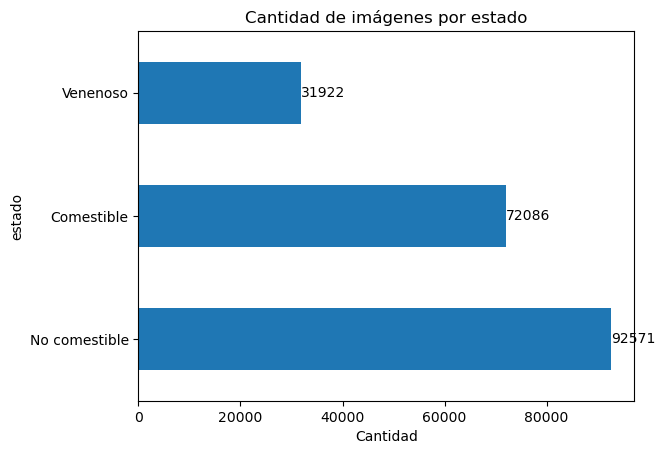

In [14]:
ax = df["estado"].value_counts().plot(kind="barh")
plt.title("Cantidad de imágenes por estado")
plt.xlabel("Cantidad")

# Agregar etiquetas con los valores en cada barra
ax.bar_label(ax.containers[0])

plt.show()

In [15]:
df["estado"].value_counts(1)

estado
No comestible    0.470910
Comestible       0.366702
Venenoso         0.162388
Name: proportion, dtype: float64

**Se observa mayor cantidad de imágenes no comestibles y comestibles versus las venenosas. En definitiva las especies venenosas se encuentran en mucho menor medida que el resto. Las No Comestibles son el triple y las Comestibles más del doble.**

## CHEQUEO DE CANTIDAD DE ESPECIES POR ESTADO

In [16]:
(df.groupby("estado")["especie"]
      .nunique()
      .sort_values(ascending=False))

estado
No comestible    220
Comestible       181
Venenoso         154
Name: especie, dtype: int64

In [17]:
# proporción de registros
prop_registros = df["estado"].value_counts(normalize=True)

# proporción de especies únicas
prop_especies = (
    df.groupby("estado")["especie"].nunique().sort_values(ascending=False)
    / df.groupby("estado")["especie"].nunique().sum()
)

# combinar en un solo DataFrame
comparacion = pd.DataFrame({
    "Proporción de registros": prop_registros,
    "Proporción de especies únicas": prop_especies
})
comparacion

,Proporción de registros,Proporción de especies únicas
estado,,
No comestible,0.470910,0.396396
Comestible,0.366702,0.326126
Venenoso,0.162388,0.277477


**Nos responde a la duda de si el desbalance de cantidad de imágenes por estado viene por el lado de que hay menos especies venenosas por ejemplo o si dentro de las que son venenosas hay menos fotos que con el resto de las categorías**

Confirmado que es así: en cantidad de imágenes las venenosas representan 16% pero en cantidad de especies representan un 27%.
En las otras dos categorías el impacto es menor, guardando cierta similitud entre cantidad de imágenes y cantidad de especies.

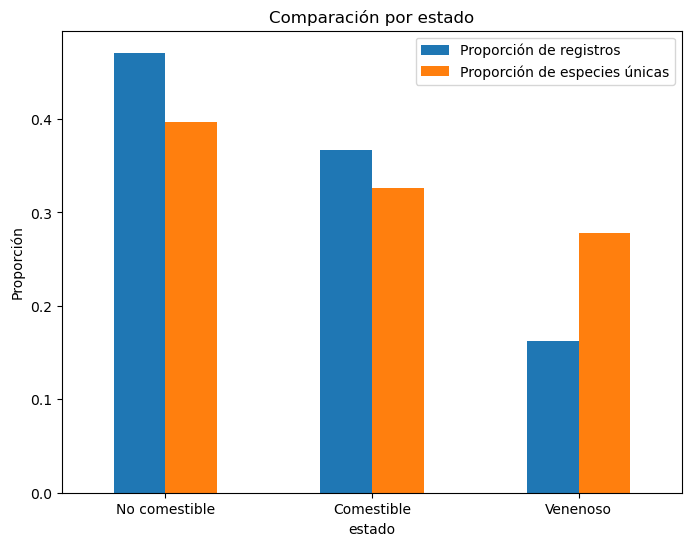

In [18]:
comparacion.plot(kind="bar", figsize=(8,6))
plt.title("Comparación por estado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

## TOP 30 ESPECIES

In [19]:
totales_por_especie = (df.groupby(["especie","estado"])
                         .size()
                         .reset_index(name="imagenes")
                         .sort_values("imagenes", ascending=False))

In [20]:
top = totales_por_especie.head(30)

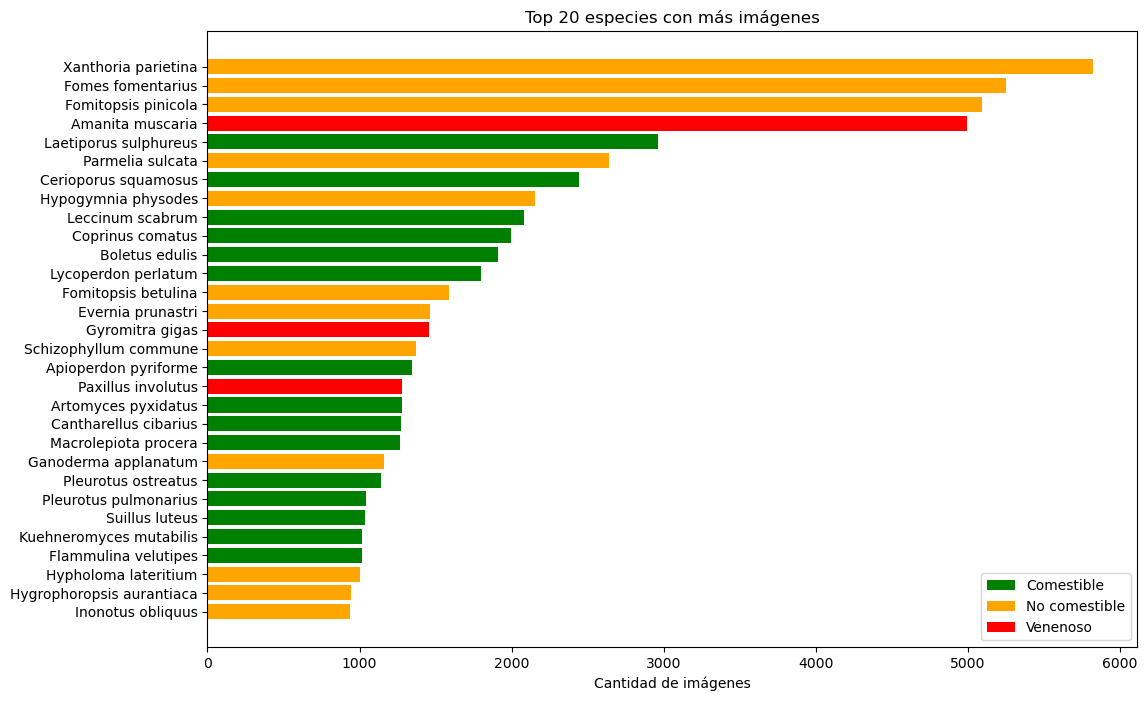

In [21]:
plt.figure(figsize=(12,8))

plt.barh(
    top["especie"],
    top["imagenes"],
    color=top["estado"].map(colores)
)

legend_elements = [
    Patch(facecolor="green", label="Comestible"),
    Patch(facecolor="orange", label="No comestible"),
    Patch(facecolor="red", label="Venenoso")
]

plt.legend(handles=legend_elements)

plt.gca().invert_yaxis()

plt.xlabel("Cantidad de imágenes")
plt.title("Top 20 especies con más imágenes")

plt.show()

**Nos permite visualizar si está sesgado a cierto estado o si están balanceadas las especies más representativas, lo cual nos ayudará para luego decidir sobre qué especies quedan fuera del split de Train**

## HISTOGRAMA Y QUANTILES

In [22]:
imgs_por_especie = df["especie"].value_counts()

imgs_por_especie.describe()

count     555.000000
mean      354.196396
std       552.417074
min        12.000000
25%        37.000000
50%       297.000000
75%       357.500000
max      5823.000000
Name: count, dtype: float64

In [23]:
imgs_por_especie = df.groupby("especie").size()

print(imgs_por_especie.quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

0.01      14.00
0.05      23.00
0.10      27.00
0.25      37.00
0.50     297.00
0.75     357.50
0.90     695.20
0.95     960.80
0.99    2532.62
dtype: float64


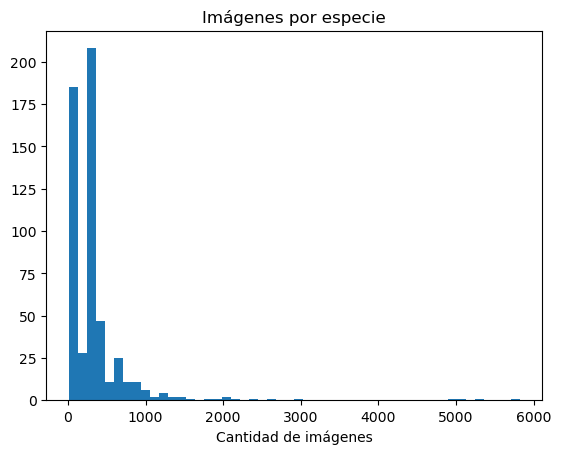

In [24]:
plt.hist(imgs_por_especie, bins=50)
plt.title("Imágenes por especie")
plt.xlabel("Cantidad de imágenes")
plt.show()

**Se confirma lo que se viene viendo que hay una concentración muy fuerte de especies cuya cantidad de imágenes es muy poca en relación con los outliers que tenemos con ejemplares de 3mil imágenes o más**

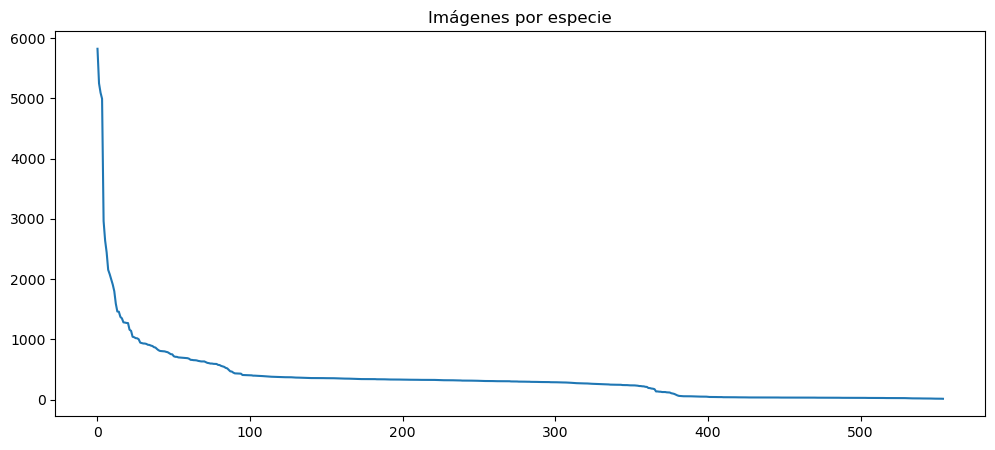

In [25]:
especies = df.groupby("especie").size()

plt.figure(figsize=(12,5))
plt.plot(sorted(especies.values, reverse=True))
plt.title("Imágenes por especie")
plt.show()

**Este otro gráfico complementa al histograma: cae muy fuertemente en seguida, lo cual habla de la poca cantidad de especies cuya cantidad de imágenes es elevada, luego de cierto umbral se convierte casi en una asíntota horizontal.**

## CHEQUEO DE DUPLICADOS

In [26]:
df["nombre_archivo"] = (
    df["archivo"]
      .apply(lambda x: os.path.basename(x))
)

duplicados = (
    df["nombre_archivo"]
      .value_counts()
)

duplicados[duplicados > 1]

Series([], Name: count, dtype: int64)

**Se chequeó para descartar que no haya duplicados y que tambien eso no implique data leakage en caso de partir el split y que el modelo vea una misma foto dos veces**.

In [27]:
df

,archivo,especie,estado,fuente,nombre_archivo
0,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original,Agaricus arvensis_1.webp
1,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original,Agaricus arvensis_10.webp
2,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original,Agaricus arvensis_100.webp
3,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original,Agaricus arvensis_101.webp
4,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original,Agaricus arvensis_102.webp
...,...,...,...,...,...
196574,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomellus chrysenteron,Comestible,scrapper,xerocomellus-chrysenteron_4.jpg
196575,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper,xerocomus-subtomentosus_1.jpg
196576,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper,xerocomus-subtomentosus_2.jpg
196577,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper,xerocomus-subtomentosus_3.jpg


# UNA VEZ TERMINADO EL EDA, SE VA A GENERAR CIERTO GRUPO MAS REDUCIDO DE IMÁGENES CON LOS CUALES SE VA A ENTRENAR, YA QUE EL TAMAÑO DEL DATASET SINO ES MUY GRANDE: 3%

**Aquí se decide cómo se va a hacer la toma aleatoria de todas las especies:**

In [28]:
%%time
# ==========================
    # RECORREMOS TODAS LAS ESPECIES
    # ==========================

for especie in df["especie"].unique():

    df_especie = df[df["especie"] == especie]

    originales = df_especie[df_especie["fuente"] == "original"]

    scraper = df_especie[df_especie["fuente"] == "scrapper"]

    total = len(df_especie)

    # ==========================
    # QUEREMOS TOTALIZAR EN UN 3% DEL TOTAL DE IMAGENES QUE HAYA POR ESPECIE. 
    # SI EL 3% ES MENOR A 25 IMÁGENES, ENTONCES SE TOMAN 25 AL AZAR DENTRO DE CADA ESPECIE.
    # Y SI DE POR SÍ EL DATASET DE CADA ESPECIE TIENE MENOS QUE 25, SE QUEDA CON TODAS LAS IMÁGENES.
    # ADICIONALMENTE, SIEMPRE TIENE PRIORIDAD EL DATASET DE SCRAPPER QUE SON MENOS IMAGENES (4 POR CADA ESPECIE)
    # ==========================
    
    if total < 25:
        cantidad = total
    else:
        cantidad = max(25, int(total * 0.03))

    cantidad = min(cantidad, total)

    cantidad_scraper = len(scraper)

    cantidad_original = max(
        0,
        cantidad - cantidad_scraper
    )


    originales_seleccionadas = originales.sample(
        n=min(cantidad_original, len(originales)),
        random_state=42
    )

    # ==========================
    # ACA SE JUNTAN LOS DOS DATASET
    # ==========================
    
    seleccionadas = pd.concat(
        [
            scraper,
            originales_seleccionadas
        ],
        ignore_index=True
    )


    # ==========================
    # GUARDAR DATASET
    # ==========================

    carpeta_salida = os.path.join(output_dir_3, especie)
    os.makedirs(carpeta_salida, exist_ok=True)

    for _, fila in seleccionadas.iterrows():

        origen = fila["archivo"]
        fuente = fila["fuente"]

        nombre = os.path.splitext(
            os.path.basename(origen)
        )[0]

        # --------------------------
        # IMÁGENES ORIGINALES (.webp)
        # --------------------------
        if fuente == "original":

            destino = os.path.join(
                carpeta_salida,
                os.path.basename(origen)
            )

            shutil.copy2(origen, destino)

        # --------------------------
        # IMÁGENES DEL SCRAPPER (.jpg)
        # --------------------------
        else:

            destino = os.path.join(
                carpeta_salida,
                nombre + "_scr.webp"
            )

            imagen = Image.open(origen)

            imagen.save(
                destino,
                "WEBP"
            )

print("✅ Dataset generado correctamente.")

✅ Dataset generado correctamente.
CPU times: total: 12min 42s
Wall time: 14min 46s


In [29]:
extensiones = (".webp")

conteo_3 = {}

for clase in os.listdir(output_dir_3):
    clase_path = os.path.join(output_dir_3, clase)
    if os.path.isdir(clase_path):
        imagenes = [f for f in os.listdir(clase_path)
                    if os.path.isfile(os.path.join(clase_path, f)) and f.lower().endswith(extensiones)]
        conteo_3[clase] = len(imagenes)

# Mostrar resultados ordenados por cantidad
for clase, cantidad in sorted(conteo_3.items(), key=lambda x: x[1], reverse=True):
    print(f"{clase}: {cantidad} imágenes")

print(f"\nTotal de imágenes: {sum(conteo_3.values())}")
print(f"Total de clases: {len(conteo_3)}")

Xanthoria parietina: 174 imágenes
Fomes fomentarius: 157 imágenes
Fomitopsis pinicola: 152 imágenes
Amanita muscaria: 149 imágenes
Laetiporus sulphureus: 88 imágenes
Parmelia sulcata: 79 imágenes
Cerioporus squamosus: 73 imágenes
Hypogymnia physodes: 64 imágenes
Leccinum scabrum: 62 imágenes
Coprinus comatus: 59 imágenes
Boletus edulis: 57 imágenes
Lycoperdon perlatum: 53 imágenes
Fomitopsis betulina: 47 imágenes
Evernia prunastri: 43 imágenes
Gyromitra gigas: 43 imágenes
Schizophyllum commune: 41 imágenes
Apioperdon pyriforme: 40 imágenes
Artomyces pyxidatus: 38 imágenes
Cantharellus cibarius: 38 imágenes
Macrolepiota procera: 38 imágenes
Paxillus involutus: 38 imágenes
Ganoderma applanatum: 34 imágenes
Pleurotus ostreatus: 34 imágenes
Pleurotus pulmonarius: 31 imágenes
Suillus luteus: 31 imágenes
Flammulina velutipes: 30 imágenes
Hypholoma lateritium: 30 imágenes
Kuehneromyces mutabilis: 30 imágenes
Hygrophoropsis aurantiaca: 28 imágenes
Inonotus obliquus: 28 imágenes
Amanita rubesce

In [30]:
sum(conteo_3.values())

14721

# AL SET DE IMÁGENES QUE QUEDÓ SE LE VUELVE A HACER UN EDA, YA QUE SUFRIÓ TRANSFORMACIONES:

# SE HACE EL CONTEO POR ESTADO

In [31]:
registros = []

for clase in os.listdir(output_dir_3):

    clase_path = os.path.join(output_dir_3, clase)

    if not os.path.isdir(clase_path):
        continue

    estado = estado_hongos.get(clase)

    if estado is None:
        print(f"No encontré: {clase}")
        continue

    for archivo in os.listdir(clase_path):

        if archivo.lower().endswith(".webp"):

            registros.append({
                "archivo": os.path.join(clase_path, archivo),
                "especie": clase,
                "estado": estado
            })

df = pd.DataFrame(registros)

df["estado"].value_counts()

estado
No comestible    6078
Comestible       4846
Venenoso         3797
Name: count, dtype: int64

# SE GENERA EL DATAFRAME CON LA IMAGEN CORRESPONDIENTE, QUÉ ESPECIE ES Y SU ESTADO

In [32]:
df

,archivo,especie,estado
0,C:\Datasets\imagenes_como_vienen\3%\Agaricus a...,Agaricus arvensis,Comestible
1,C:\Datasets\imagenes_como_vienen\3%\Agaricus a...,Agaricus arvensis,Comestible
2,C:\Datasets\imagenes_como_vienen\3%\Agaricus a...,Agaricus arvensis,Comestible
3,C:\Datasets\imagenes_como_vienen\3%\Agaricus a...,Agaricus arvensis,Comestible
4,C:\Datasets\imagenes_como_vienen\3%\Agaricus a...,Agaricus arvensis,Comestible
...,...,...,...
14716,C:\Datasets\imagenes_como_vienen\3%\Xeromphali...,Xeromphalina campanella,No comestible
14717,C:\Datasets\imagenes_como_vienen\3%\Xeromphali...,Xeromphalina campanella,No comestible
14718,C:\Datasets\imagenes_como_vienen\3%\Xeromphali...,Xeromphalina campanella,No comestible
14719,C:\Datasets\imagenes_como_vienen\3%\Xeromphali...,Xeromphalina campanella,No comestible


# EDA:

## CHEQUEO DE CANTIDAD DE FOTOS POR ESTADO

In [33]:
df["estado"].value_counts()

estado
No comestible    6078
Comestible       4846
Venenoso         3797
Name: count, dtype: int64

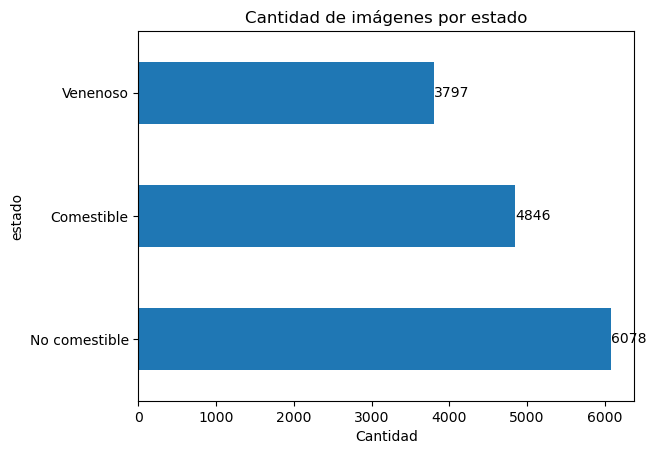

In [34]:
ax = df["estado"].value_counts().plot(kind="barh")
plt.title("Cantidad de imágenes por estado")
plt.xlabel("Cantidad")

# Agregar etiquetas con los valores en cada barra
ax.bar_label(ax.containers[0])

plt.show()

**Se observa que como eran más representativas las especies de comestible y no comestible en cantidad de imágenes, al hacer la selección del 3% de cada una de ellas y tomando como mínimo 25 imágenes por especie, se logra minimizar las diferencias. Ahora el peso relativo de cada estado está mejor repartido entre las 3 posibilidades, y eso se debe a que las especies venenosas en general tenían menos cantidad de ejemplares, y por eso se torna más representativa.**

## CHEQUEO DE CANTIDAD DE ESPECIES POR ESTADO

In [35]:
(
    df.groupby("estado")["especie"]
      .nunique()
      .sort_values(ascending=False)
)

estado
No comestible    220
Comestible       181
Venenoso         154
Name: especie, dtype: int64

In [36]:
# proporción de registros
prop_registros = df["estado"].value_counts(normalize=True)

# proporción de especies únicas
prop_especies = (
    df.groupby("estado")["especie"].nunique().sort_values(ascending=False)
    / df.groupby("estado")["especie"].nunique().sum()
)

# combinar en un solo DataFrame
comparacion = pd.DataFrame({
    "Proporción de registros": prop_registros,
    "Proporción de especies únicas": prop_especies
})
comparacion

,Proporción de registros,Proporción de especies únicas
estado,,
No comestible,0.412880,0.396396
Comestible,0.329190,0.326126
Venenoso,0.257931,0.277477


**Aqui podemos notar que efectivamente se logró representar de mejor manera las especies venenosas, pasando a representar un 26% en lugar del 16% en el dataset original.**

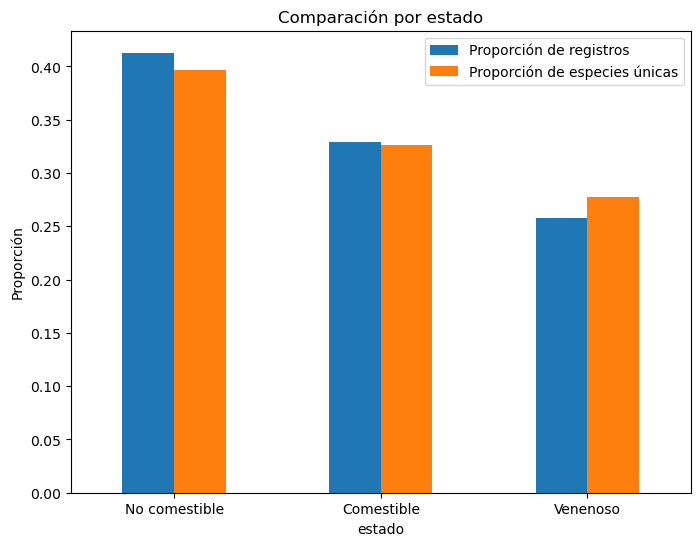

In [37]:
comparacion.plot(kind="bar", figsize=(8,6))
plt.title("Comparación por estado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

**Aquí se ve lo que comentamos arriba: quedó mejor representado la cantidad de registros si lo comparamos con la cantidad de especies.**

## TOP 30 ESPECIES

In [38]:
totales_por_especie = (df.groupby(["especie","estado"])
                         .size()
                         .reset_index(name="imagenes")
                         .sort_values("imagenes", ascending=False))

In [39]:
top = totales_por_especie.head(30)

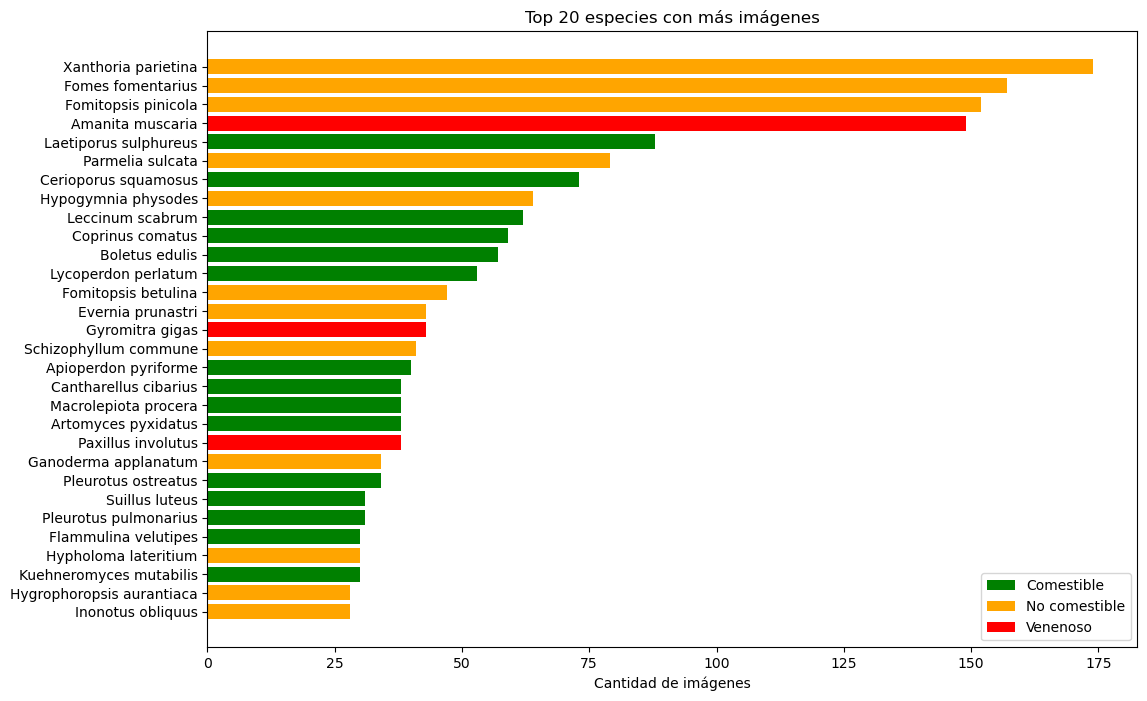

In [40]:
plt.figure(figsize=(12,8))

plt.barh(
    top["especie"],
    top["imagenes"],
    color=top["estado"].map(colores)
)

legend_elements = [
    Patch(facecolor="green", label="Comestible"),
    Patch(facecolor="orange", label="No comestible"),
    Patch(facecolor="red", label="Venenoso")
]

plt.legend(handles=legend_elements)

plt.gca().invert_yaxis()

plt.xlabel("Cantidad de imágenes")
plt.title("Top 20 especies con más imágenes")

plt.show()

**Nos permite visualizar si está sesgado a cierto estado o si están balanceadas las especies más representativas, lo cual nos ayudará para luego decidir sobre qué especies quedan fuera del split de Train**

## HISTOGRAMA Y QUANTILES

In [41]:
imgs_por_especie = df["especie"].value_counts()

imgs_por_especie.describe()

count    555.000000
mean      26.524324
std       12.705667
min       12.000000
25%       25.000000
50%       25.000000
75%       25.000000
max      174.000000
Name: count, dtype: float64

In [42]:
imgs_por_especie = df.groupby("especie").size()

print(imgs_por_especie.quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

0.01    14.00
0.05    23.00
0.10    25.00
0.25    25.00
0.50    25.00
0.75    25.00
0.90    25.00
0.95    28.60
0.99    75.76
dtype: float64


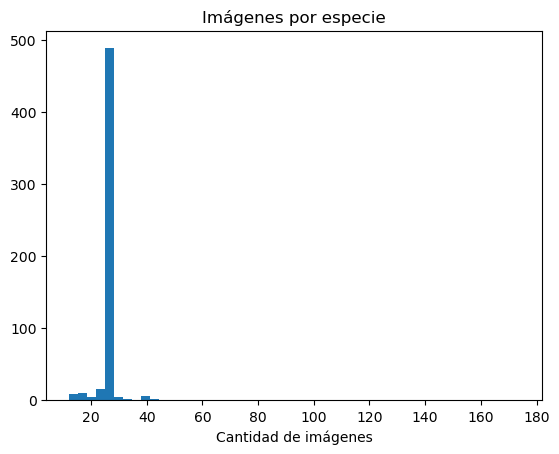

In [43]:
plt.hist(imgs_por_especie, bins=50)
plt.title("Imágenes por especie")
plt.xlabel("Cantidad de imágenes")
plt.show()

**Se confirma lo que se viene viendo que hay una concentración muy fuerte de especies cuya cantidad de imágenes es muy poca en relación con los outliers que tenemos con ejemplares de 100 imágenes o más**

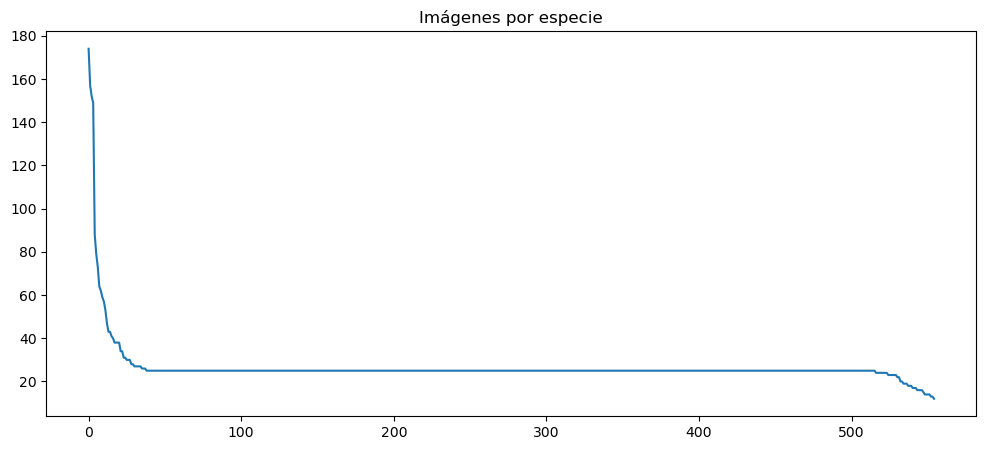

In [44]:
especies = df.groupby("especie").size()

plt.figure(figsize=(12,5))
plt.plot(sorted(especies.values, reverse=True))
plt.title("Imágenes por especie")
plt.show()

**Este otro gráfico complementa al histograma: cae muy fuertemente en seguida, lo cual habla de la poca cantidad de especies cuya cantidad de imágenes es elevada, luego de cierto umbral se convierte casi en una asíntota horizontal.**

## CHEQUEO DE DUPLICADOS

In [45]:
df["nombre_archivo"] = (
    df["archivo"]
      .apply(lambda x: os.path.basename(x))
)

duplicados = (
    df["nombre_archivo"]
      .value_counts()
)

duplicados[duplicados > 1]

Series([], Name: count, dtype: int64)

**Se chequeó para descartar que no haya duplicados y que tambien eso no implique data leakage en caso de partir el split y que el modelo vea una misma foto dos veces**.

# UNA VEZ TERMINADO EL EDA AL NUEVO SET DE IMAGENES, ELEGIMOS CIERTAS ESPECIES QUE NO SERÁN PARTE DEL ENTRENAMIENTO

In [46]:
print(totales_por_especie.shape)
totales_por_especie.imagenes.sum()

(555, 3)


14721

## SE TOMAN 20 ESPECIES POR CADA ESTADO, CUYO TOTAL DE IMÁGENES ES DE 25, POR LO TANTO SE TERMINAN TOMANDO 500 IMÁGENES PARA VALIDACIÓN EN PRODUCCIÓN

In [47]:
cantidad_casos = 25

especies_produccion_no_com = totales_por_especie[(totales_por_especie['estado']=='No comestible') & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie
especies_produccion_com    = totales_por_especie[(totales_por_especie['estado']=='Comestible')    & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie
especies_produccion_ven    = totales_por_especie[(totales_por_especie['estado']=='Venenoso')      & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie

In [48]:
df_produccion    = df[(df["especie"].isin(especies_produccion_no_com)) |
                      (df["especie"].isin(especies_produccion_com))    | 
                      (df["especie"].isin(especies_produccion_ven))]

df_entrenamiento = df[~df["especie"].isin(df_produccion.especie)].copy()

In [49]:
print(len(df_produccion))
print(len(df_entrenamiento))

1500
13221


**ACA VERIFICAMOS CUANTAS ESPECIES QUEDARON (PARTIMOS DE 555 Y LE SACAMOS 60) → TIENEN QUE QUEDAR 495**

In [50]:
df_entrenamiento.especie.nunique()

495

## CHEQUEAMOS PROPORCIÓN ACTUAL DEL df_entrenamiento

In [51]:
# proporción de registros
prop_registros = df_entrenamiento["estado"].value_counts(normalize=True)

# proporción de especies únicas
prop_especies = (
    df_entrenamiento.groupby("estado")["especie"].nunique().sort_values(ascending=False)
    / df_entrenamiento.groupby("estado")["especie"].nunique().sum()
)

# combinar en un solo DataFrame
comparacion = pd.DataFrame({
    "Proporción de registros": prop_registros,
    "Proporción de especies únicas": prop_especies
})
comparacion

,Proporción de registros,Proporción de especies únicas
estado,,
No comestible,0.421905,0.404040
Comestible,0.328719,0.325253
Venenoso,0.249376,0.270707


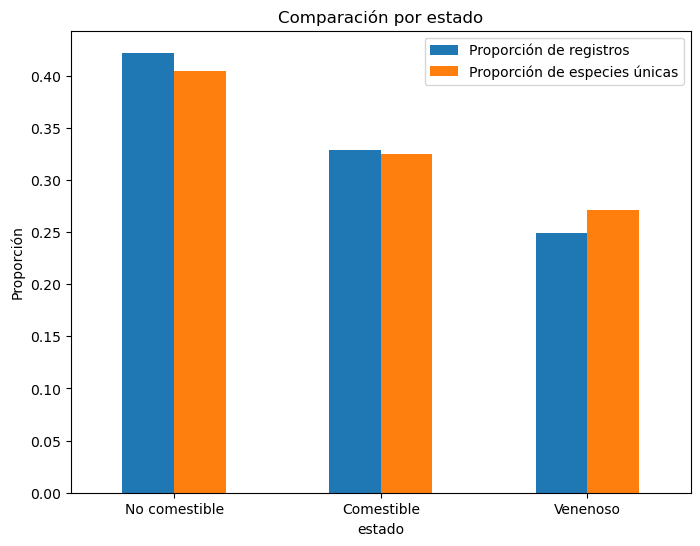

In [52]:
comparacion.plot(kind="bar", figsize=(8,6))
plt.title("Comparación por estado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

## AHORA HAY QUE PARTIR ESTE df_entrenamiento ENTRE TRAIN Y TEST Y TENER EL CUIDADO DE QUE NINGUNA IMAGEN DE CIERTA ESPECIE QUEDE TANTO EN EL SPLIT DE TRAIN COMO EN EL DE TEST Y ASÍ IMPEDIR EL DATA LEAKAGE

In [53]:
totales_entrenamiento = (
    df_entrenamiento
    .groupby(["especie", "estado"])
    .size()
    .reset_index(name="imagenes")
)

totales_entrenamiento

,especie,estado,imagenes
0,Agaricus augustus,Comestible,25
1,Agaricus bernardii,Comestible,25
2,Agaricus bisporus,Comestible,25
3,Agaricus californicus,Venenoso,25
4,Agaricus campestris,Comestible,25
...,...,...,...
490,Vulpicida pinastri,No comestible,25
491,Xanthoria parietina,No comestible,174
492,Xerocomellus chrysenteron,Comestible,25
493,Xerocomus subtomentosus,Comestible,25


In [54]:
SEED = 42

especies_test = (
    totales_entrenamiento
    .groupby("estado", group_keys=False)
    .apply(lambda x: x.sample(frac=0.20, random_state=SEED))
)

C:\Users\santi\AppData\Local\Temp\ipykernel_3352\3682985992.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.20, random_state=SEED))


In [55]:
especies_test.shape

(99, 3)

In [56]:
especies_test.estado.value_counts()

estado
No comestible    40
Comestible       32
Venenoso         27
Name: count, dtype: int64

## AQUI SE GENERAN LOS DOS DATASET:

In [57]:
especies_test = especies_test["especie"]

df_test = df_entrenamiento[df_entrenamiento["especie"].isin(especies_test)]

df_train = df_entrenamiento[~df_entrenamiento["especie"].isin(especies_test)]

## SE OBSERVA EL PESO RELATIVO DE CADA ESTADO EN AMBOS SPLIT

In [58]:
print(df_train["estado"].value_counts(1))
print(df_test["estado"].value_counts(1))

estado
No comestible    0.430062
Comestible       0.320057
Venenoso         0.249881
Name: proportion, dtype: float64
estado
No comestible    0.389761
Comestible       0.362855
Venenoso         0.247384
Name: proportion, dtype: float64


In [59]:
print(df_train["especie"].nunique())
print(df_test["especie"].nunique())

396
99


## POR ÚLTIMO, EL PESO RELATIVO DEL TEST EN EL TOTAL

In [60]:
(
    df_test.groupby("estado")
           .size()
           /
    df_entrenamiento.groupby("estado").size()
)

estado
Comestible       0.223424
No comestible    0.186985
Venenoso         0.200789
dtype: float64

## YA ENTRAMOS EN LA ETAPA DE ENTRENAR EL MODELO PRÁCTICAMENTE...

In [61]:
df_train["label"] = df_train["estado"].map(mapeo)
df_test["label"] = df_test["estado"].map(mapeo)

C:\Users\santi\AppData\Local\Temp\ipykernel_3352\2863937230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["label"] = df_train["estado"].map(mapeo)
C:\Users\santi\AppData\Local\Temp\ipykernel_3352\2863937230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["label"] = df_test["estado"].map(mapeo)


In [62]:
df_train["estado"].value_counts(normalize=True)

estado
No comestible    0.430062
Comestible       0.320057
Venenoso         0.249881
Name: proportion, dtype: float64

In [63]:
df_test["estado"].value_counts(normalize=True)

estado
No comestible    0.389761
Comestible       0.362855
Venenoso         0.247384
Name: proportion, dtype: float64

# ACA ENVIAMOS EL DATASET A OTRA CARPETA

In [64]:
output_train       = "C:\\Datasets\\imagenes_como_vienen\\3%\\dataset_train_jpg"
output_test        = "C:\\Datasets\\imagenes_como_vienen\\3%\\dataset_test_jpg"
output_produccion  = "C:\\Datasets\\imagenes_como_vienen\\3%\\dataset_produccion_jpg"

In [65]:
%%time
os.makedirs(output_train, exist_ok=True)

for _, row in df_train.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_train, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset TRAIN generado")

✅ Dataset TRAIN generado
CPU times: total: 5min 21s
Wall time: 9min 46s


In [66]:
%%time
os.makedirs(output_test, exist_ok=True)

for _, row in df_test.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_test, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset TEST generado")

✅ Dataset TEST generado
CPU times: total: 1min 21s
Wall time: 2min 32s


In [67]:
%%time
os.makedirs(output_produccion, exist_ok=True)

for _, row in df_produccion.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_produccion, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset PRODUCCION generado")

✅ Dataset PRODUCCION generado
CPU times: total: 42.3 s
Wall time: 1min 22s


In [68]:
for nombre, dataset in {
    "TRAIN": df_train,
    "TEST": df_test,
    "PRODUCCION": df_produccion
}.items():

    print(f"\n{nombre}")
    print(dataset["estado"].value_counts())


TRAIN
estado
No comestible    4535
Comestible       3375
Venenoso         2635
Name: count, dtype: int64

TEST
estado
No comestible    1043
Comestible        971
Venenoso          662
Name: count, dtype: int64

PRODUCCION
estado
Comestible       500
Venenoso         500
No comestible    500
Name: count, dtype: int64


# TOMANDO 15% DEL TOTAL DE IMAGENES

# UNA VEZ TERMINADO EL EDA, SE VA A GENERAR CIERTO GRUPO MAS REDUCIDO DE IMÁGENES CON LOS CUALES SE VA A ENTRENAR, YA QUE EL TAMAÑO DEL DATASET SINO ES MUY GRANDE: 15%

**Aquí se decide cómo se va a hacer la toma aleatoria de todas las especies:**

In [69]:
df_respaldo

,archivo,especie,estado,fuente
0,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
1,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
2,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
3,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
4,C:\Datasets\imagenes_como_vienen\images\Agaric...,Agaricus arvensis,Comestible,original
...,...,...,...,...
196574,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomellus chrysenteron,Comestible,scrapper
196575,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper
196576,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper
196577,C:\Datasets\imagenes_como_vienen\scrapper\xero...,Xerocomus subtomentosus,Comestible,scrapper


In [70]:
%%time
    # ==========================
    # RECORREMOS TODAS LAS ESPECIES
    # ==========================

for especie in df_respaldo["especie"].unique():

    df_especie = df_respaldo[df_respaldo["especie"] == especie]

    originales = df_especie[df_especie["fuente"] == "original"]

    scraper = df_especie[df_especie["fuente"] == "scrapper"]

    total = len(df_especie)

    # ==========================
    # QUEREMOS TOTALIZAR EN UN 15% DEL TOTAL DE IMAGENES QUE HAYA POR ESPECIE. 
    # SI EL 15% ES MENOR A 100 IMÁGENES, ENTONCES SE TOMAN 100 AL AZAR DENTRO DE CADA ESPECIE.
    # Y SI DE POR SÍ EL DATASET DE CADA ESPECIE TIENE MENOS QUE 100, SE QUEDA CON TODAS LAS IMÁGENES.
    # ADICIONALMENTE, SIEMPRE TIENE PRIORIDAD EL DATASET DE SCRAPPER QUE SON MENOS IMAGENES (4 POR CADA ESPECIE)
    # ==========================
    
    if total < 100:
        cantidad = total
    else:
        cantidad = max(100, int(total * 0.15))

    cantidad = min(cantidad, total)

    cantidad_scraper = len(scraper)

    cantidad_original = max(
        0,
        cantidad - cantidad_scraper
    )


    originales_seleccionadas = originales.sample(
        n=min(cantidad_original, len(originales)),
        random_state=42
    )

    # ==========================
    # ACA SE JUNTAN LOS DOS DATASET
    # ==========================
    
    seleccionadas = pd.concat(
        [
            scraper,
            originales_seleccionadas
        ],
        ignore_index=True
    )


    # ==========================
    # GUARDAR DATASET
    # ==========================

    carpeta_salida = os.path.join(output_dir_15, especie)
    os.makedirs(carpeta_salida, exist_ok=True)

    for _, fila in seleccionadas.iterrows():

        origen = fila["archivo"]
        fuente = fila["fuente"]

        nombre = os.path.splitext(
            os.path.basename(origen)
        )[0]

        # --------------------------
        # IMÁGENES ORIGINALES (.webp)
        # --------------------------
        if fuente == "original":

            destino = os.path.join(
                carpeta_salida,
                os.path.basename(origen)
            )

            shutil.copy2(origen, destino)

        # --------------------------
        # IMÁGENES DEL SCRAPPER (.jpg)
        # --------------------------
        else:

            destino = os.path.join(
                carpeta_salida,
                nombre + "_scr.webp"
            )

            imagen = Image.open(origen)

            imagen.save(
                destino,
                "WEBP"
            )

print("✅ Dataset generado correctamente.")

✅ Dataset generado correctamente.
CPU times: total: 15min 14s
Wall time: 20min 31s


In [71]:
extensiones = (".webp")

conteo_15 = {}

for clase in os.listdir(output_dir_15):
    clase_path = os.path.join(output_dir_15, clase)
    if os.path.isdir(clase_path):
        imagenes = [f for f in os.listdir(clase_path)
                    if os.path.isfile(os.path.join(clase_path, f)) and f.lower().endswith(extensiones)]
        conteo_15[clase] = len(imagenes)

# Mostrar resultados ordenados por cantidad
for clase, cantidad in sorted(conteo_15.items(), key=lambda x: x[1], reverse=True):
    print(f"{clase}: {cantidad} imágenes")

print(f"\nTotal de imágenes: {sum(conteo_15.values())}")
print(f"Total de clases: {len(conteo_15)}")

Xanthoria parietina: 873 imágenes
Fomes fomentarius: 787 imágenes
Fomitopsis pinicola: 764 imágenes
Amanita muscaria: 748 imágenes
Laetiporus sulphureus: 444 imágenes
Parmelia sulcata: 395 imágenes
Cerioporus squamosus: 366 imágenes
Hypogymnia physodes: 322 imágenes
Leccinum scabrum: 312 imágenes
Coprinus comatus: 299 imágenes
Boletus edulis: 286 imágenes
Lycoperdon perlatum: 269 imágenes
Fomitopsis betulina: 238 imágenes
Evernia prunastri: 219 imágenes
Gyromitra gigas: 218 imágenes
Schizophyllum commune: 205 imágenes
Apioperdon pyriforme: 202 imágenes
Paxillus involutus: 192 imágenes
Artomyces pyxidatus: 191 imágenes
Cantharellus cibarius: 190 imágenes
Macrolepiota procera: 190 imágenes
Ganoderma applanatum: 173 imágenes
Pleurotus ostreatus: 171 imágenes
Pleurotus pulmonarius: 156 imágenes
Suillus luteus: 155 imágenes
Flammulina velutipes: 152 imágenes
Kuehneromyces mutabilis: 152 imágenes
Hypholoma lateritium: 150 imágenes
Hygrophoropsis aurantiaca: 141 imágenes
Inonotus obliquus: 14

In [72]:
sum(conteo_15.values())

50135

# AL SET DE IMÁGENES QUE QUEDÓ SE LE VUELVE A HACER UN EDA, YA QUE SUFRIÓ TRANSFORMACIONES:

# SE HACE EL CONTEO POR ESTADO

In [73]:
registros = []

for clase in os.listdir(output_dir_15):

    clase_path = os.path.join(output_dir_15, clase)

    if not os.path.isdir(clase_path):
        continue

    estado = estado_hongos.get(clase)

    if estado is None:
        print(f"No encontré: {clase}")
        continue

    for archivo in os.listdir(clase_path):

        if archivo.lower().endswith(".webp"):

            registros.append({
                "archivo": os.path.join(clase_path, archivo),
                "especie": clase,
                "estado": estado
            })

df = pd.DataFrame(registros)

df["estado"].value_counts()

estado
No comestible    23035
Comestible       17672
Venenoso          9428
Name: count, dtype: int64

# SE GENERA EL DATAFRAME CON LA IMAGEN CORRESPONDIENTE, QUÉ ESPECIE ES Y SU ESTADO

In [74]:
df

,archivo,especie,estado
0,C:\Datasets\imagenes_como_vienen\15%\Agaricus ...,Agaricus arvensis,Comestible
1,C:\Datasets\imagenes_como_vienen\15%\Agaricus ...,Agaricus arvensis,Comestible
2,C:\Datasets\imagenes_como_vienen\15%\Agaricus ...,Agaricus arvensis,Comestible
3,C:\Datasets\imagenes_como_vienen\15%\Agaricus ...,Agaricus arvensis,Comestible
4,C:\Datasets\imagenes_como_vienen\15%\Agaricus ...,Agaricus arvensis,Comestible
...,...,...,...
50130,C:\Datasets\imagenes_como_vienen\15%\Xeromphal...,Xeromphalina campanella,No comestible
50131,C:\Datasets\imagenes_como_vienen\15%\Xeromphal...,Xeromphalina campanella,No comestible
50132,C:\Datasets\imagenes_como_vienen\15%\Xeromphal...,Xeromphalina campanella,No comestible
50133,C:\Datasets\imagenes_como_vienen\15%\Xeromphal...,Xeromphalina campanella,No comestible


# EDA:

## CHEQUEO DE CANTIDAD DE FOTOS POR ESTADO

In [75]:
df["estado"].value_counts()

estado
No comestible    23035
Comestible       17672
Venenoso          9428
Name: count, dtype: int64

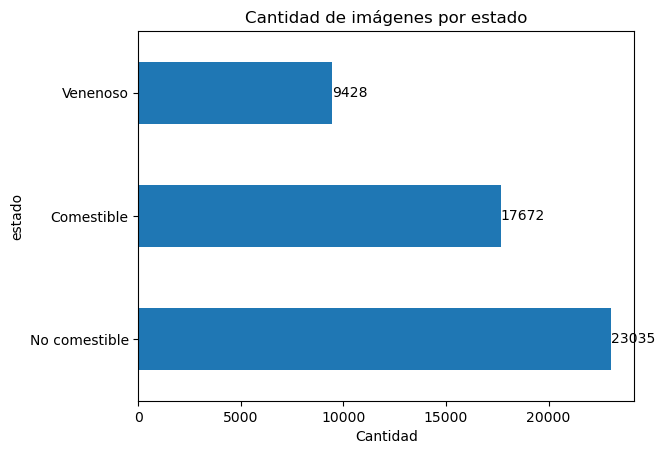

In [76]:
ax = df["estado"].value_counts().plot(kind="barh")
plt.title("Cantidad de imágenes por estado")
plt.xlabel("Cantidad")

# Agregar etiquetas con los valores en cada barra
ax.bar_label(ax.containers[0])

plt.show()

**Se observa que al tomar un porcentaje mayor, se volvió a quedar más desbalanceada la cantidad de especies venenosas.**

## CHEQUEO DE CANTIDAD DE ESPECIES POR ESTADO

In [77]:
(
    df.groupby("estado")["especie"]
      .nunique()
      .sort_values(ascending=False)
)

estado
No comestible    220
Comestible       181
Venenoso         154
Name: especie, dtype: int64

In [78]:
# proporción de registros
prop_registros = df["estado"].value_counts(normalize=True)

# proporción de especies únicas
prop_especies = (
    df.groupby("estado")["especie"].nunique().sort_values(ascending=False)
    / df.groupby("estado")["especie"].nunique().sum()
)

# combinar en un solo DataFrame
comparacion = pd.DataFrame({
    "Proporción de registros": prop_registros,
    "Proporción de especies únicas": prop_especies
})
comparacion

,Proporción de registros,Proporción de especies únicas
estado,,
No comestible,0.459459,0.396396
Comestible,0.352488,0.326126
Venenoso,0.188052,0.277477


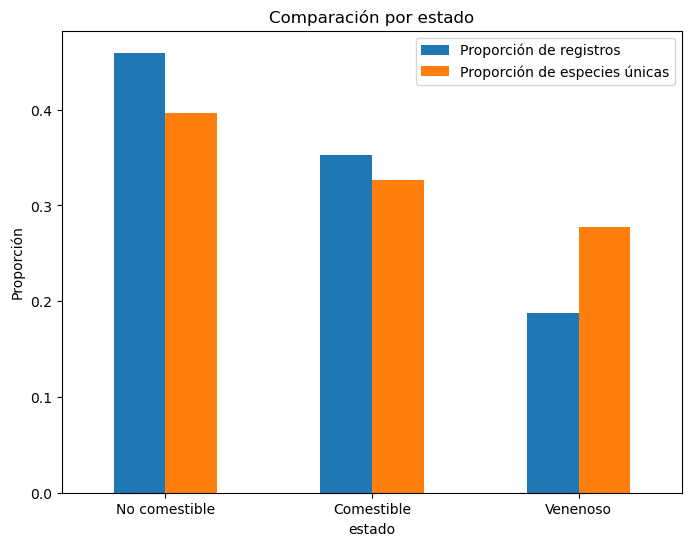

In [79]:
comparacion.plot(kind="bar", figsize=(8,6))
plt.title("Comparación por estado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

**Aquí se logra ver como dejó de estar igualado la barra azul y naranja, que muestra cuanto era el peso relativo de la cantidad de fotos de especies venenosas y comparado con la cantidad de especies venenosas sobre el total.**

## TOP 30 ESPECIES

In [80]:
totales_por_especie = (df.groupby(["especie","estado"])
                         .size()
                         .reset_index(name="imagenes")
                         .sort_values("imagenes", ascending=False))

In [81]:
top = totales_por_especie.head(30)

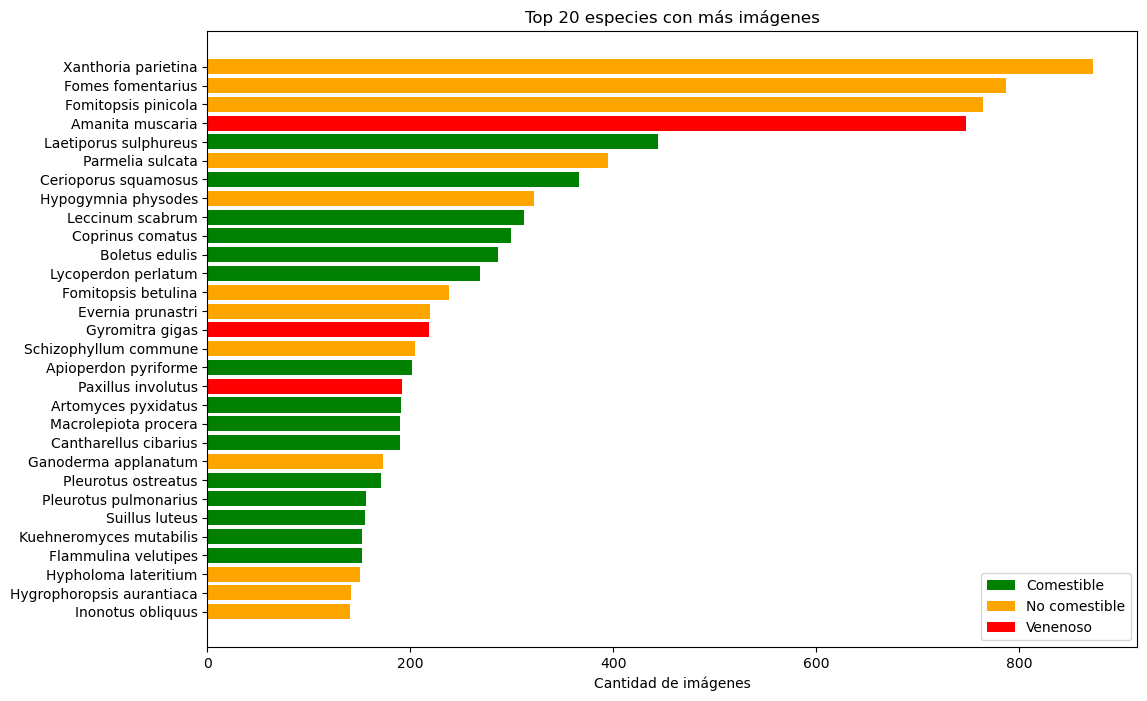

In [82]:
plt.figure(figsize=(12,8))

plt.barh(
    top["especie"],
    top["imagenes"],
    color=top["estado"].map(colores)
)

legend_elements = [
    Patch(facecolor="green", label="Comestible"),
    Patch(facecolor="orange", label="No comestible"),
    Patch(facecolor="red", label="Venenoso")
]

plt.legend(handles=legend_elements)

plt.gca().invert_yaxis()

plt.xlabel("Cantidad de imágenes")
plt.title("Top 20 especies con más imágenes")

plt.show()

**Nos permite visualizar si está sesgado a cierto estado o si están balanceadas las especies más representativas, lo cual nos ayudará para luego decidir sobre qué especies quedan fuera del split de Train**

## HISTOGRAMA Y QUANTILES

In [83]:
imgs_por_especie = df["especie"].value_counts()

imgs_por_especie.describe()

count    555.000000
mean      90.333333
std       77.604493
min       12.000000
25%       37.000000
50%      100.000000
75%      100.000000
max      873.000000
Name: count, dtype: float64

In [84]:
imgs_por_especie = df.groupby("especie").size()

print(imgs_por_especie.quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

0.01     14.00
0.05     23.00
0.10     27.00
0.25     37.00
0.50    100.00
0.75    100.00
0.90    104.00
0.95    143.70
0.99    379.34
dtype: float64


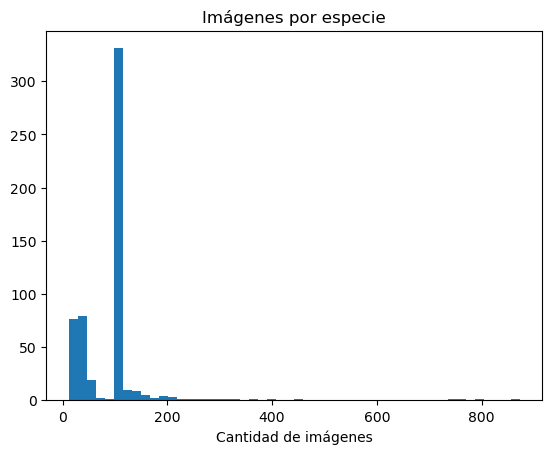

In [85]:
plt.hist(imgs_por_especie, bins=50)
plt.title("Imágenes por especie")
plt.xlabel("Cantidad de imágenes")
plt.show()

**Se confirma lo que se viene viendo que hay una concentración muy fuerte de especies cuya cantidad de imágenes es muy poca en relación con los outliers que tenemos con ejemplares de 400 imágenes o más**

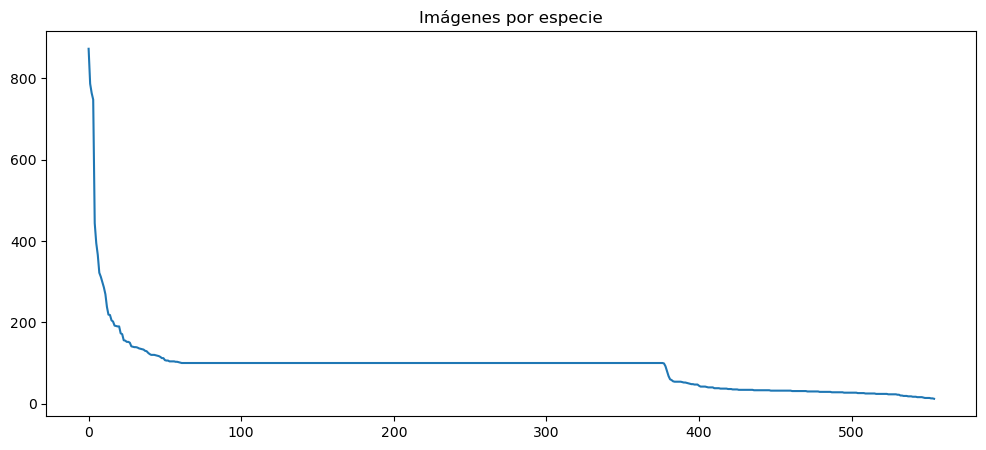

In [86]:
especies = df.groupby("especie").size()

plt.figure(figsize=(12,5))
plt.plot(sorted(especies.values, reverse=True))
plt.title("Imágenes por especie")
plt.show()

**Este otro gráfico complementa al histograma: cae muy fuertemente en seguida, lo cual habla de la poca cantidad de especies cuya cantidad de imágenes es elevada, luego de cierto umbral se convierte casi en una asíntota horizontal.**

## CHEQUEO DE DUPLICADOS

In [87]:
df["nombre_archivo"] = (
    df["archivo"]
      .apply(lambda x: os.path.basename(x))
)

duplicados = (
    df["nombre_archivo"]
      .value_counts()
)

duplicados[duplicados > 1]

Series([], Name: count, dtype: int64)

**Se chequeó para descartar que no haya duplicados y que tambien eso no implique data leakage en caso de partir el split y que el modelo vea una misma foto dos veces**.

# UNA VEZ TERMINADO EL EDA AL NUEVO SET DE IMAGENES, ELEGIMOS CIERTAS ESPECIES QUE NO SERÁN PARTE DEL ENTRENAMIENTO

In [88]:
print(totales_por_especie.shape)
totales_por_especie.imagenes.sum()

(555, 3)


50135

## SE TOMAN 20 ESPECIES POR CADA ESTADO, CUYO TOTAL DE IMÁGENES ES DE 25, POR LO TANTO SE TERMINAN TOMANDO 500 IMÁGENES PARA VALIDACIÓN EN PRODUCCIÓN

In [89]:
cantidad_casos = 100

especies_produccion_no_com = totales_por_especie[(totales_por_especie['estado']=='No comestible') & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie
especies_produccion_com    = totales_por_especie[(totales_por_especie['estado']=='Comestible')    & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie
especies_produccion_ven    = totales_por_especie[(totales_por_especie['estado']=='Venenoso')      & (totales_por_especie['imagenes']<=cantidad_casos)].head(20).especie

In [90]:
df_produccion    = df[(df["especie"].isin(especies_produccion_no_com)) |
                      (df["especie"].isin(especies_produccion_com))    | 
                      (df["especie"].isin(especies_produccion_ven))]

df_entrenamiento = df[~df["especie"].isin(df_produccion.especie)].copy()

In [91]:
print(len(df_produccion))
print(len(df_entrenamiento))

6000
44135


**ACA VERIFICAMOS CUANTAS ESPECIES QUEDARON (PARTIMOS DE 555 Y LE SACAMOS 60) → TIENEN QUE QUEDAR 495**

In [92]:
df_entrenamiento.especie.nunique()

495

## CHEQUEAMOS PROPORCIÓN ACTUAL DEL df_entrenamiento

In [93]:
# proporción de registros
prop_registros = df_entrenamiento["estado"].value_counts(normalize=True)

# proporción de especies únicas
prop_especies = (
    df_entrenamiento.groupby("estado")["especie"].nunique().sort_values(ascending=False)
    / df_entrenamiento.groupby("estado")["especie"].nunique().sum()
)

# combinar en un solo DataFrame
comparacion = pd.DataFrame({
    "Proporción de registros": prop_registros,
    "Proporción de especies únicas": prop_especies
})
comparacion

,Proporción de registros,Proporción de especies únicas
estado,,
No comestible,0.476606,0.404040
Comestible,0.355092,0.325253
Venenoso,0.168302,0.270707


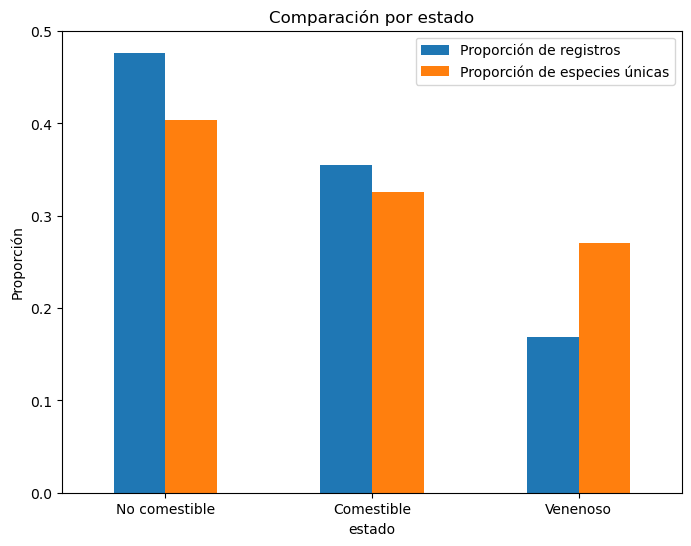

In [94]:
comparacion.plot(kind="bar", figsize=(8,6))
plt.title("Comparación por estado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

## AHORA HAY QUE PARTIR ESTE df_entrenamiento ENTRE TRAIN Y TEST Y TENER EL CUIDADO DE QUE NINGUNA IMAGEN DE CIERTA ESPECIE QUEDE TANTO EN EL SPLIT DE TRAIN COMO EN EL DE TEST Y ASÍ IMPEDIR EL DATA LEAKAGE

In [95]:
totales_entrenamiento = (
    df_entrenamiento
    .groupby(["especie", "estado"])
    .size()
    .reset_index(name="imagenes")
)

totales_entrenamiento

,especie,estado,imagenes
0,Agaricus augustus,Comestible,104
1,Agaricus bernardii,Comestible,100
2,Agaricus bisporus,Comestible,54
3,Agaricus californicus,Venenoso,48
4,Agaricus campestris,Comestible,100
...,...,...,...
490,Vulpicida pinastri,No comestible,129
491,Xanthoria parietina,No comestible,873
492,Xerocomellus chrysenteron,Comestible,100
493,Xerocomus subtomentosus,Comestible,100


In [96]:
SEED = 42

especies_test = (
    totales_entrenamiento
    .groupby("estado", group_keys=False)
    .apply(lambda x: x.sample(frac=0.20, random_state=SEED))
)

C:\Users\santi\AppData\Local\Temp\ipykernel_3352\3682985992.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.20, random_state=SEED))


In [97]:
especies_test.shape

(99, 3)

In [98]:
especies_test.estado.value_counts()

estado
No comestible    40
Comestible       32
Venenoso         27
Name: count, dtype: int64

## AQUI SE GENERAN LOS DOS DATASET:

In [99]:
especies_test = especies_test["especie"]

df_test = df_entrenamiento[df_entrenamiento["especie"].isin(especies_test)]

df_train = df_entrenamiento[~df_entrenamiento["especie"].isin(especies_test)]

## SE OBSERVA EL PESO RELATIVO DE CADA ESTADO EN AMBOS SPLIT

In [100]:
print(df_train["estado"].value_counts(1))
print(df_test["estado"].value_counts(1))

estado
No comestible    0.485721
Comestible       0.343740
Venenoso         0.170539
Name: proportion, dtype: float64
estado
No comestible    0.443702
Comestible       0.396073
Venenoso         0.160226
Name: proportion, dtype: float64


In [101]:
print(df_train["especie"].nunique())
print(df_test["especie"].nunique())

396
99


## POR ÚLTIMO, EL PESO RELATIVO DEL TEST EN EL TOTAL

In [102]:
(
    df_test.groupby("estado")
           .size()
           /
    df_entrenamiento.groupby("estado").size()
)

estado
Comestible       0.241960
No comestible    0.201949
Venenoso         0.206516
dtype: float64

## YA ENTRAMOS EN LA ETAPA DE ENTRENAR EL MODELO PRÁCTICAMENTE...

In [103]:
df_train["label"] = df_train["estado"].map(mapeo)
df_test["label"] = df_test["estado"].map(mapeo)

C:\Users\santi\AppData\Local\Temp\ipykernel_3352\2863937230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["label"] = df_train["estado"].map(mapeo)
C:\Users\santi\AppData\Local\Temp\ipykernel_3352\2863937230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["label"] = df_test["estado"].map(mapeo)


In [104]:
df_train["estado"].value_counts(normalize=True)

estado
No comestible    0.485721
Comestible       0.343740
Venenoso         0.170539
Name: proportion, dtype: float64

In [105]:
df_test["estado"].value_counts(normalize=True)

estado
No comestible    0.443702
Comestible       0.396073
Venenoso         0.160226
Name: proportion, dtype: float64

# ACA ENVIAMOS EL DATASET A OTRA CARPETA

In [106]:
output_train       = "C:\\Datasets\\imagenes_como_vienen\\15%\\dataset_train_jpg"
output_test        = "C:\\Datasets\\imagenes_como_vienen\\15%\\dataset_test_jpg"
output_produccion  = "C:\\Datasets\\imagenes_como_vienen\\15%\\dataset_produccion_jpg"

In [107]:
%%time
os.makedirs(output_train, exist_ok=True)

for _, row in df_train.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_train, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset TRAIN generado")

✅ Dataset TRAIN generado
CPU times: total: 15min 25s
Wall time: 30min 4s


In [108]:
%%time
os.makedirs(output_test, exist_ok=True)

for _, row in df_test.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_test, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset TEST generado")

✅ Dataset TEST generado
CPU times: total: 4min 13s
Wall time: 7min 40s


In [109]:
%%time
os.makedirs(output_produccion, exist_ok=True)

for _, row in df_produccion.iterrows():

    estado = row["estado"]
    origen = row["archivo"]

    carpeta_estado = os.path.join(output_produccion, estado)
    os.makedirs(carpeta_estado, exist_ok=True)

    nombre_jpg = os.path.splitext(
        os.path.basename(origen)
    )[0] + ".jpg"

    destino = os.path.join(
        carpeta_estado,
        nombre_jpg
    )

    try:
        img = Image.open(origen)

        img.convert("RGB").save(
            destino,
            "JPEG",
            quality=95
        )

    except Exception as e:
        print(f"Error en {origen}: {e}")

print("✅ Dataset PRODUCCION generado")

✅ Dataset PRODUCCION generado
CPU times: total: 2min 15s
Wall time: 4min 43s


In [110]:
for nombre, dataset in {
    "TRAIN": df_train,
    "TEST": df_test,
    "PRODUCCION": df_produccion
}.items():

    print(f"\n{nombre}")
    print(dataset["estado"].value_counts())


TRAIN
estado
No comestible    16787
Comestible       11880
Venenoso          5894
Name: count, dtype: int64

TEST
estado
No comestible    4248
Comestible       3792
Venenoso         1534
Name: count, dtype: int64

PRODUCCION
estado
Comestible       2000
No comestible    2000
Venenoso         2000
Name: count, dtype: int64


# Y AQUÍ SE GENERA EL DATA AUGMENTATION PARA LAS ESPECIES VENENOSAS

In [8]:
train_original     = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg"
train_aug          = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg_aug"

In [9]:
if os.path.exists(train_aug):
    shutil.rmtree(train_aug)

shutil.copytree(train_original, train_aug)

print("Dataset copiado")

Dataset copiado


In [10]:
carpeta_venenoso = os.path.join(train_aug, "Venenoso")

imagenes = [
    f for f in os.listdir(carpeta_venenoso)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

In [11]:
objetivo = 11000

faltan = objetivo - len(imagenes)

print(f"Generando {faltan} imágenes nuevas")

Generando 5106 imágenes nuevas


In [12]:
for i in range(faltan):

    archivo = random.choice(imagenes)

    ruta = os.path.join(carpeta_venenoso, archivo)

    img = Image.open(ruta)

    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    angulo = random.uniform(-10, 10)

    img = img.rotate(angulo)

    nombre_nuevo = f"aug_{i}_{archivo}"

    destino = os.path.join(
        carpeta_venenoso,
        nombre_nuevo
    )

    img.save(destino)